In [ ]:
'''
필수 의존 라이브러리 (conda prompt 기준)
anaconda prompt 안에서 pip install 진행

1. scanpy lib
pip install scanpy jupyter matplotlib seaborn

2. pooch, leidenalg
pip install scanpy pooch leidenalg

3. Doublet detection시, 사용
pip install scikit-image
'''

C:\Users\82108\AppData\Local\Temp\ipykernel_9484\1148418568.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


1.11.5
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


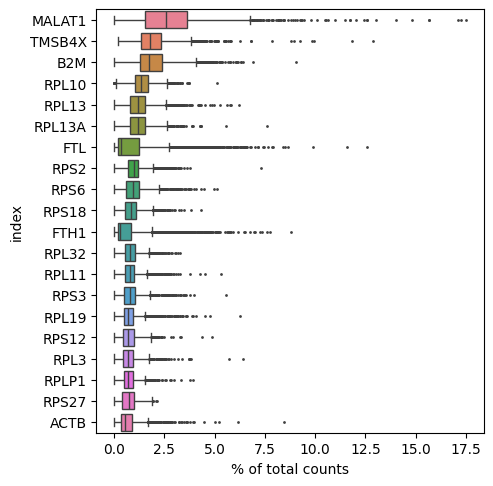

In [5]:
import scanpy as sc
print(sc.__version__)

adata = sc.datasets.pbmc3k()
print(adata)

sc.pl.highest_expr_genes(adata, n_top=20)

### 1. Preprocessing and clustering

해당 데이터는 기본적인 전처리와 클러스터링 튜토리얼로,  NeurIPS 2021 벤치마킹 데이터 셋 중 건강한 사람의 골수 단핵세포 중 일부를 기증 받아서 제작 되었다.

이 샘플은 이 튜토리얼에서 사용되는데 정확히 잰 10X 멀티옴 유전자 발현과 크로마틴 접근성 키트이다.

count matrix를 Anndata 객체로 읽어낸다. 여기에는 데이터의 주석과 다양한 표현 방식을 담는 여러 슬롯을 가지고 있다. 더 자세히 알고싶으면 anndata 튜토리얼 참고

In [3]:
# scverse의 주요 라이브러리
from __future__ import annotations

import anndata as ad

# 데이터 검색
import pooch
import scanpy as sc

sc.settings.set_figure_params(dpi=50, facecolor="white")

In [4]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [5]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata
    
adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts)
adata

c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<bound method IndexOpsMixin.value_counts of AAACCCAAGGATGGCT-1    s1d1
AAACCCAAGGCCTAGA-1    s1d1
AAACCCAAGTGAGTGC-1    s1d1
AAACCCACAAGAGGCT-1    s1d1
AAACCCACATCGTGGC-1    s1d1
                      ... 
TTTGTTGAGAGTCTGG-1    s1d3
TTTGTTGCAGACAATA-1    s1d3
TTTGTTGCATGTTACG-1    s1d3
TTTGTTGGTAGTCACT-1    s1d3
TTTGTTGTCGCGCTGA-1    s1d3
Name: sample, Length: 17125, dtype: category
Categories (2, object): ['s1d1', 's1d3']>


c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

이 데이터는 약 8000개의 세포와 36601개의 측정 된 유전자를 포함한다. 이제 이 기초적인 전처리와 클러스터링 작업과정을 조사해보자.

### Quality Control

`calculate_qc_metrics()` 함수는 일반적인 QC 지표를 계산한다. scater의 `calculateQCMetrics`를 기반으로 한다. 특정 유전자 집단을 함수에 전달하면 해당 집단의 카운트 비율을 계산할 수 있다. 미토콘드리아, 리보솜, 헤모글로빈 유전자는 아래에 나열된 접두사(**prefix**) 로 구분된다.

In [ ]:
# mitochondrial genes, "MT-" 접두사라면 사람, "Mt-" 접두사라면 쥐
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [7]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

QC 행렬로 계산 된 violin 구성들을 확인 할 수 있다.

- 행렬 수로 표현 된 유전자의 번호들
- 세포의 총 퍼센트 수
- 미토콘드리아의 퍼센테이지 수

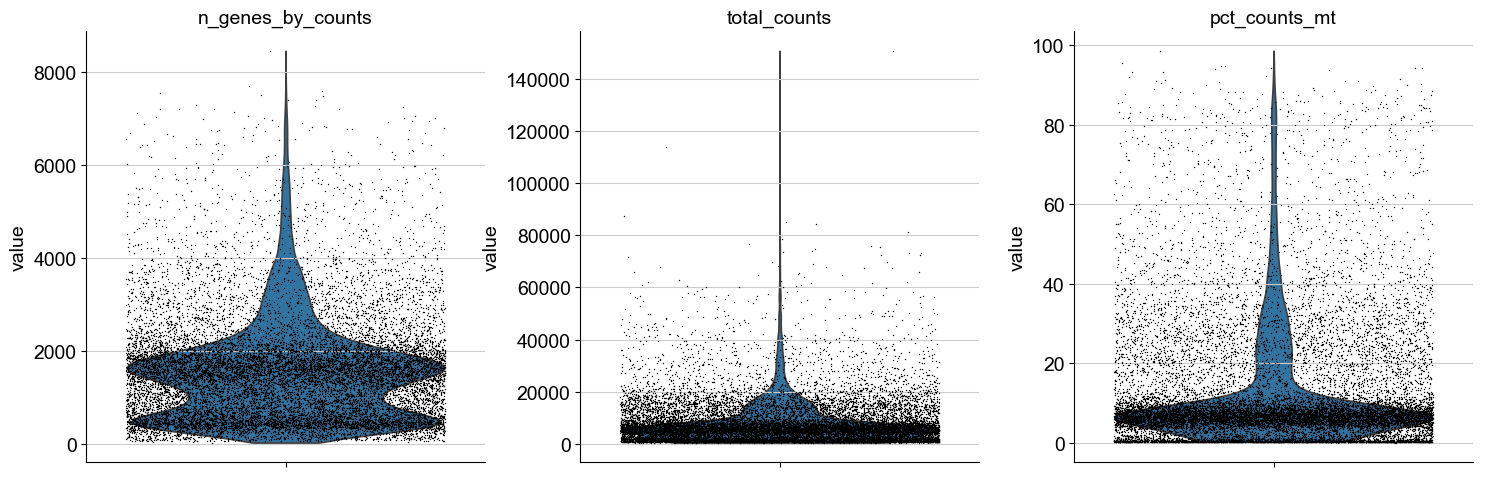

In [8]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

추가적으로 ptc_counts_mt로 색칠 된 산점도 그래프를 검사하는데에는 QC 지표를 함께 보는 것이 더 유용하다.

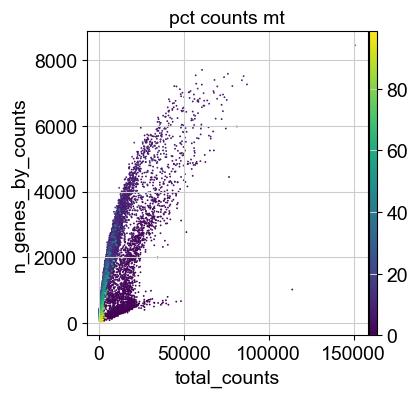

In [9]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

QC지표를 기반으로 세포를 지워야 할때는 너무 많은 미토콘드리이가 표현되어있거나 총 개수가 너무 많다면 지침서 또는 자동 임계값으로 설정한다.

그러나 종종 이상한 QC지표가 실제 생물학적 현상 때문일 수 있으니 전략적으로 매우 허용적인 필터링으로 나중에 다시 검토한다.

그러므로 세포는 100개 이하로 표현하게하고 유전자는 3개 이하로 발견되는 것만 필터링한다.

추가적으로 이것은 데이터셋의 병렬배치에 매우 중요한 메모인데 QC는 임계값을 배치사이에서 상당히 다양하게 개별적으로 수행한다.

In [10]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

## Doublet detection

다음 단계는 Doublet detection 알고리즘이다.

doublet를 식별하는 것은 중요한데, 잘못 된 분류를 하거나 downstream 분석단계에서 왜곡을 유발 할 수 있기 때문이다.

Scanpy는 doublet 탐지 메서드를 가지고있다. Scrublet은 관측된 전사체와 시뮬레이션 된 doublet의 최근접 이웃 분류기를 사용하여 doublet을 예측한다.

*scanpy.pp.scrublet()*는 *doublet_score*과 *predicted_doublet*를 *obs*에 추가한다.
*predicted_doublet*으로 바로 필터링 하거나 *doublet_score*가 나중에 높은 클러스터를 걸러내는 동안 사용할 수 있다.

In [ ]:
sc.pp.scrublet(adata, batch_key="sample")

doublet로 판정 된 세포를 바로 필터링하거나, 클러스터링이 끝나고 높은 doublet 스코어를 가진 클러스터를 지우는 방시긍로 doublet를 지울 수 있다.

## Normalization

다음 전처리 단계는 정규화이다.

흔한 접근방식은 count depth scaling 후 **log1p** 변환을 적용하는 것이다.
count depth scaling은 데이터를 “size factor”로 정규화하는데, 데이터셋의 중앙값 count depth, **CP10k** 또는 **CPM** 같은거로 한다.
size factor는 *pp.normalize_total* 안의 *target_sum* 울 통해 count depth scaling을 할 수 있다.
깊이 정규화 중앙값 수를 log1p 변환을 통해 나타낸다 (log1PF라고도 불린다).

**log1p = log plus one**
**CP10k = count per ten thousand**
**CPM = count per one million**

In [15]:
# count data 저장하기
adata.layers["counts"] = adata.X.copy()

In [17]:
# 중앙값 total counts를 정규화 하기
sc.pp.normalize_total(adata)
# 데이터 로그 변환
sc.pp.log1p(adata)

### Feature selection

다음 단계는 데이터셋의 차원을 줄이고 가장 유익한 유전자들을 포함하는 것이다.
이 단계에서는 흔하게 아는 feature selection라고 한다.
Scanpy 함수 중에 *pp.highly_variable_gens*는 선택한 *flavor*에 따라 Seurat, Cell Ranger 그리고 Seurat v3의 구현 방식을 재현하여 highly variable gene에 주석을 단다.

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

In [ ]:
sc.pp.highly_variable_genes(adata)